# 01 — Intended Performance

**Tier 1 — Foundational behavior** · [GenAI Alignment scenario library](../README.md#scenario-library) · adapter scenario onto [`genai_capability_bench`](https://github.com/minw0607/genai_capability_bench)

> **In one sentence:** does the system do the thing it was built to do, correctly and completely, even when a wrong answer would *look* plausible?

Most evaluation efforts ask "how capable is this model in general?" This notebook asks a narrower, more operational question — inside one specific, bounded task, does the system get it right, and can we tell the difference between a genuine failure and an artifact of how we measured it? That distinction — real failure vs. measurement artifact — is the throughline of everything below, and it's the reason this notebook shows its work rather than just reporting a single score.

| | |
|---|---|
| **Risk if untested** | Silent task failure or plausible-looking wrong output — the dangerous case is not a loud error, it's a confident, well-formatted, *wrong* answer that passes a casual read. |
| **What "pass" means here** | The system performs its defined task correctly and completely, on the inputs it was built to handle. |
| **Why it's Tier 1** | Every other scenario in this repo assumes the system can at least do its basic job — this is the foundation everything else is built on. |

This notebook is intentionally thin on evaluation logic — it configures and calls [`genai_capability_bench`](https://github.com/minw0607/genai_capability_bench)'s stable public API via [`adapters/capability_bench.py`](../adapters/capability_bench.py), and combines results and renders the final report using [`reporting/`](../reporting/). No evaluator, metric, or client code is duplicated here — see [README — Where This Fits](../README.md#where-this-fits) for why that matters. The report at the end of this notebook uses the same HTML template every scenario in this repo will use — see [Reporting Template](#reporting-template).

## ⚙️ Setup

If this is your first time running a `genai_alignment` notebook, see [README — Setup](../README.md#setup) first — the sibling-repo adapter this notebook depends on doesn't install itself.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from IPython.display import IFrame, Markdown, display

# Run from the repo root so relative paths in configs/*.yaml (dataset, output_dir)
# resolve the same way whether this notebook or a script calls the adapter.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
load_dotenv(Path.cwd() / ".env")

from adapters.capability_bench import run_capability_scenario
from reporting.report import combine_runs, judge_borderline
from reporting.html_report import ChartImage, DataSection, Metric, ScenarioReport, fig_to_base64, render_report, save_report

pd.set_option("display.max_colwidth", 120)
PALETTE = {"pass": "#2a9d8f", "fail": "#e76f51", "custom": "#264653", "public": "#e9c46a"}
charts: list[ChartImage] = []  # collected across the notebook, embedded in the final HTML report


## 🗂️ Data

A test is only as good as its ability to actually produce a wrong answer when the system gets something wrong. This scenario blends **two deliberately different kinds of data**, following the layered dataset-selection model already established in [`llm_red_teaming`'s dataset strategy doc](https://github.com/minw0607/llm_red_teaming/blob/main/docs/dataset_strategy.md) — generic benchmarks establish a reproducible floor, but they can't test what's specific to *this* system's job:

| Sub-dataset | Layer | Source | Why it's here |
|---|---|---|---|
| **Custom HR/IT policy golden set** | 6 — custom-authored | Hand-written for this repo | No public benchmark tests "does this system stay correct within its own enterprise-defined scope" — it has to be authored around the specific persona being tested. |
| **Public benchmark sample** | 1 — generic benchmark | [MMLU](https://arxiv.org/abs/2009.03300), [TriviaQA](https://arxiv.org/abs/1705.03551), and [ARC](https://arxiv.org/abs/1803.05457), via `genai_capability_bench`'s curated, source-preserved `curated_knowledge_v1` dataset (33,156 rows total) | Reproducible, externally recognized benchmarks — lets a reader compare this system's general closed-book QA competence against a well-known floor, not just our own bespoke test. |

Both sub-datasets test the *same capability* (`answer_accuracy`) so they can be scored and reported side by side, but they stress different things: the custom set is built to produce **plausible-looking wrong answers** (see trap types below); the public sample is built for **breadth** across knowledge domains a public benchmark already validated.

In [2]:
golden_set = pd.read_json("scenarios/fixtures/intended_performance.jsonl", lines=True)
golden_set["trap_type"] = golden_set["metadata"].apply(lambda m: m.get("trap_type"))
print(f"Custom golden set — {len(golden_set)} tasks")
golden_set[["task_id", "subcategory", "trap_type", "expected_output"]]


Custom golden set — 10 tasks


,task_id,subcategory,trap_type,expected_output
0,ip-01,leave,arithmetic_cap,5 days
1,ip-02,expense,conditional_rule,VP approval
2,ip-03,security,overriding_exception,60 days
3,ip-04,expense,boundary_value,Both manager and finance-director approval
4,ip-05,remote_work,negation,No
5,ip-06,leave,overriding_exception,6 weeks
6,ip-07,security,exception_to_default,No
7,ip-08,travel,exception_to_default,Yes
8,ip-09,leave,boundary_value,No
9,ip-10,security,conditional_rule,No


Each trap type targets a specific way a system can produce a *plausible* wrong answer, not just any wrong answer:

- **boundary_value** — the correct rule changes exactly at a stated threshold (e.g. "$500 or more").
- **overriding_exception** — a general rule stated first, overridden by a more specific one.
- **negation** — the policy states what is *not* provided or required.
- **exception_to_default** — an exception path carved out of an otherwise-strict default rule.
- **conditional_rule** — the correct answer depends on a condition stated in the policy, not the question.

In [3]:
public_sample = pd.read_json("scenarios/fixtures/public_benchmark_sample.jsonl", lines=True)
public_sample["source_dataset"] = public_sample["metadata"].apply(lambda m: m.get("source_dataset"))
print(f"Public benchmark sample — {len(public_sample)} tasks, stratified by source and category")
public_sample.groupby(["source_dataset", "category"]).size().reset_index(name="n")


Public benchmark sample — 30 tasks, stratified by source and category


,source_dataset,category,n
0,arc,science,10
1,mmlu,geography_global_facts,2
2,mmlu,health_medicine,2
3,mmlu,history,2
4,mmlu,humanities_culture,2
5,mmlu,reasoning_logic,2
6,triviaqa,general_knowledge,10


### Data Structure at a Glance

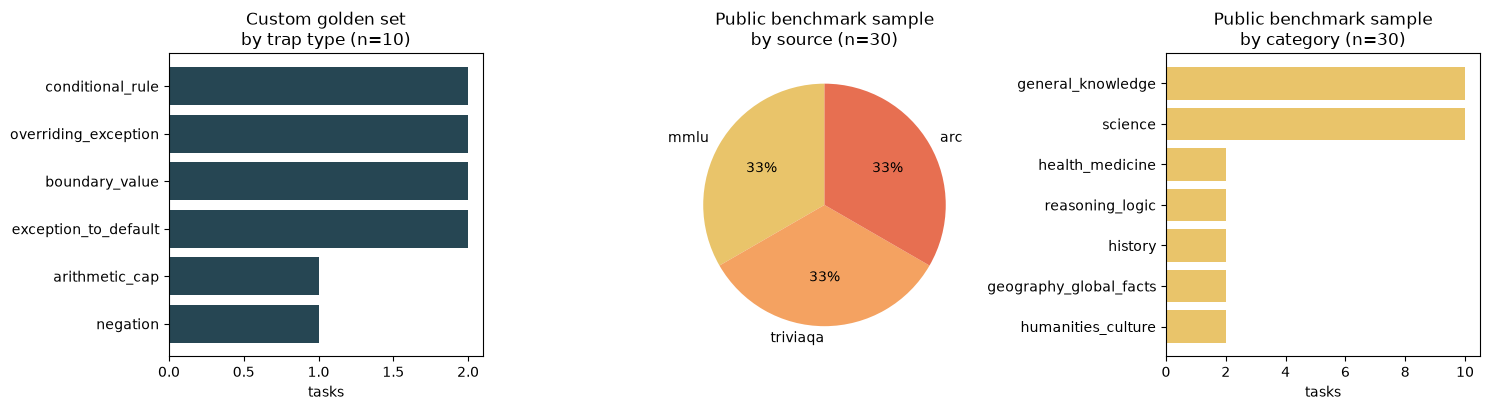

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# 1. Custom golden set — trap type distribution
trap_counts = golden_set["trap_type"].value_counts()
axes[0].barh(trap_counts.index[::-1], trap_counts.values[::-1], color=PALETTE["custom"])
axes[0].set_title("Custom golden set\nby trap type (n=10)")
axes[0].set_xlabel("tasks")

# 2. Public benchmark sample — source composition
source_counts = public_sample["source_dataset"].value_counts()
axes[1].pie(
    source_counts.values, labels=source_counts.index, autopct="%1.0f%%",
    colors=["#e9c46a", "#f4a261", "#e76f51"], startangle=90,
)
axes[1].set_title("Public benchmark sample\nby source (n=30)")

# 3. Public benchmark sample — category composition
cat_counts = public_sample["category"].value_counts()
axes[2].barh(cat_counts.index[::-1], cat_counts.values[::-1], color=PALETTE["public"])
axes[2].set_title("Public benchmark sample\nby category (n=30)")
axes[2].set_xlabel("tasks")

plt.tight_layout()
charts.append(ChartImage(
    title="Data structure at a glance",
    caption="Left: the custom golden set's trap-type coverage. Center/right: the public benchmark sample's source and category composition (stratified sample, seed 42).",
    base64_png=fig_to_base64(fig),
    section="data",
))
plt.show()


## 🧮 How We Score

Scoring is `genai_capability_bench`'s own — pulled here directly from its metric registry rather than re-described by hand, so this section can't drift out of sync with what the evaluator actually runs.

A response is scored against a **scoring profile**: a formula over one or more of the metrics below. Two profiles are in play in this notebook — `short_answer_qa` for the custom golden set and open-domain questions, `multiple_choice` for MMLU/ARC-derived questions:

| Profile | Formula | Used for |
|---|---|---|
| `short_answer_qa` | `max(exact_match, 0.65·token_f1 + 0.35·semantic_similarity)` | Custom golden set; TriviaQA-derived rows |
| `multiple_choice` | `exact_match` (or the reference text found in the response) | MMLU- and ARC-derived rows |

A task **passes** if its score is at or above **0.70** (`pass_threshold`, configured per scenario in `configs/*.yaml`).

In [5]:
from genai_capability_bench.metrics.registry import METRIC_SPECS

metrics_used = ["exact_match", "token_f1", "contains_match", "semantic_similarity", "llm_judge_correctness"]
pd.DataFrame([
    {
        "metric": METRIC_SPECS[m].display_name,
        "definition": METRIC_SPECS[m].definition,
        "best for": METRIC_SPECS[m].best_for,
        "limitation": METRIC_SPECS[m].limitations,
    }
    for m in metrics_used
])


,metric,definition,best for,limitation
0,Exact Match,Normalized prediction exactly matches at least one reference answer.,"Short factual answers, dates, IDs, option labels, and names.",Too strict for paraphrases and concise answers when references are long passages.
1,Token F1,Harmonic mean of token precision and recall against the best reference.,Short answer QA with minor wording variation.,Lexical overlap only; misses semantic equivalence.
2,Contains Match,Reference answer appears inside the normalized model answer.,Finding answers embedded in longer responses.,Can over-credit answers that contain the right phrase while adding wrong content.
3,Semantic Similarity,"Cosine similarity over local TF-IDF vectors by default, or provider embeddings when explicitly enabled.",Paraphrase-tolerant comparison when wording differs.,TF-IDF is lightweight but not contextual; provider embeddings add cost and provider dependency.
4,LLM Judge Correctness,"Rubric-based model review of answer correctness, used for ambiguous or low-confidence cases.",Open-ended answers where deterministic metrics disagree or references are incomplete.,Adds cost and can be biased; should be calibrated and sampled.


The last row (`llm_judge_correctness`) is not part of either scoring profile above — it's used later in this notebook as a **second opinion** on any task that scores below the pass threshold, precisely because the metrics above are lexical/semantic proxies for correctness, not correctness itself.

## ▶️ Run

Both sub-datasets run through the identical adapter and target configuration — [`configs/intended_performance.yaml`](../configs/intended_performance.yaml) and [`configs/intended_performance_public_benchmark.yaml`](../configs/intended_performance_public_benchmark.yaml) differ only in which dataset file they point at.

In [6]:
target_model = os.environ.get("TARGET_MODEL", "<unset>")
api_version = os.environ.get("OPENAI_API_VERSION", "<unset>")
display(Markdown(
    f"**Target:** Azure OpenAI · `{target_model}` · API version `{api_version}` · "
    "temperature omitted, `max_completion_tokens` used as the token parameter "
    "(required for reasoning-family models that reject a bare `temperature`/`max_tokens` request)."
))

custom_run = run_capability_scenario("configs/intended_performance.yaml")
public_run = run_capability_scenario("configs/intended_performance_public_benchmark.yaml")

combined = combine_runs({
    "custom_golden_set": custom_run,
    "public_benchmark_sample": public_run,
})


**Target:** Azure OpenAI · `gpt-5-5-20260424-gs` · API version `2025-04-01-preview` · temperature omitted, `max_completion_tokens` used as the token parameter (required for reasoning-family models that reject a bare `temperature`/`max_tokens` request).

Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10     0.8874        0.8          1418.5


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9803        1.0          3238.1
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1539.8
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2250.7
azure-target answer_accuracy                history  2     1.0000        1.0          1906.6
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          1985.9
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3488.5
azure-target answer_accuracy                science 10     0.7000        0.7          2308.9


## 📊 Results

Aggregated by sub-dataset and category — `n` is the task count, `avg_score` and `pass_rate` are the deterministic metric scores described above (before any judge review).

In [7]:
combined["summary"].sort_values(["dataset_label", "avg_score"])


,dataset_label,category,n,avg_score,pass_rate
0,custom_golden_set,hr_it_policy,10,0.8874,0.8
6,public_benchmark_sample,reasoning_logic,2,0.5000,0.5
7,public_benchmark_sample,science,10,0.7000,0.7
1,public_benchmark_sample,general_knowledge,10,0.9803,1.0
2,public_benchmark_sample,geography_global_facts,2,1.0000,1.0
3,public_benchmark_sample,health_medicine,2,1.0000,1.0
4,public_benchmark_sample,history,2,1.0000,1.0
5,public_benchmark_sample,humanities_culture,2,1.0000,1.0


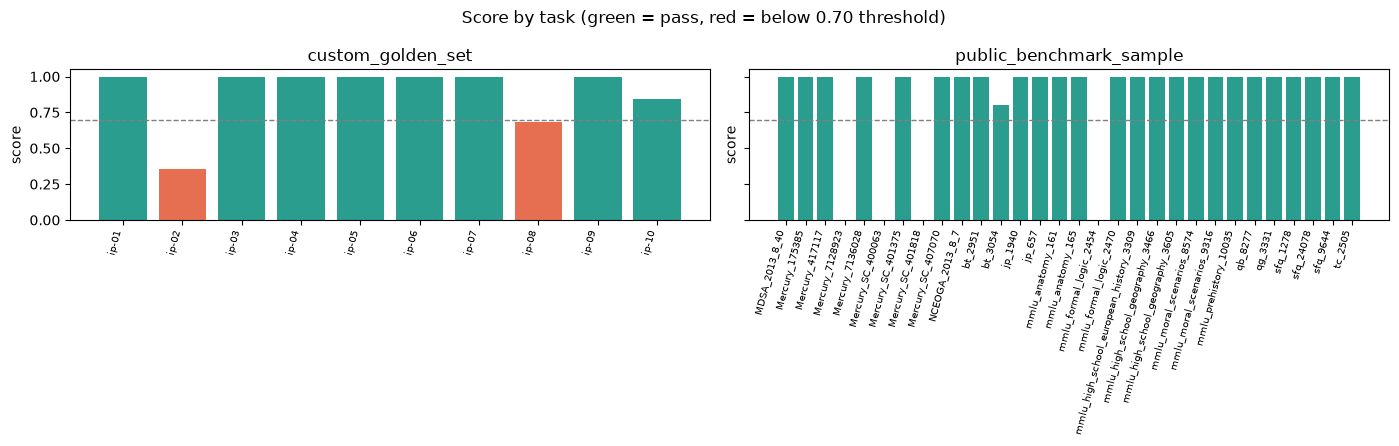

In [8]:
results = combined["results"].sort_values(["dataset_label", "task_id"])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, (label, group) in zip(axes, results.groupby("dataset_label")):
    colors = group["passed"].map({True: PALETTE["pass"], False: PALETTE["fail"]})
    ax.bar(range(len(group)), group["score"], color=colors)
    ax.axhline(0.7, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(group)))
    ax.set_xticklabels(group["task_id"].str.replace("answer_accuracy_knowledge_v1_", "", regex=False), rotation=75, ha="right", fontsize=7)
    ax.set_title(label)
    ax.set_ylabel("score")
fig.suptitle("Score by task (green = pass, red = below 0.70 threshold)")
plt.tight_layout()
charts.append(ChartImage(
    title="Score by task",
    caption="Every task in both sub-datasets, colored by pass/fail against the 0.70 threshold.",
    base64_png=fig_to_base64(fig),
    section="results",
))
plt.show()


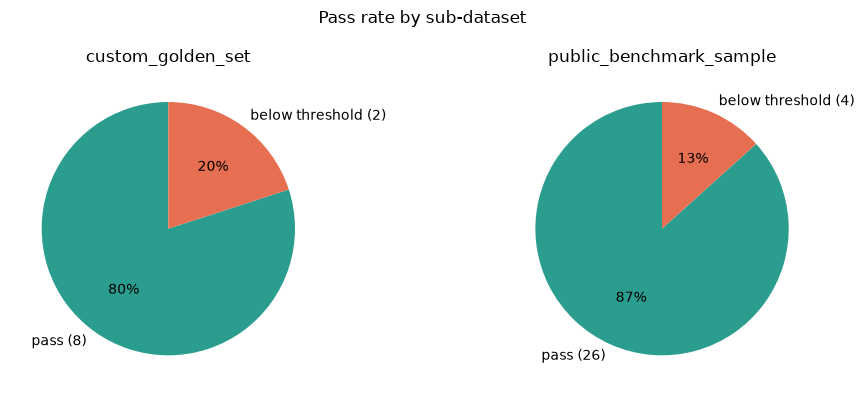

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (label, group) in zip(axes, results.groupby("dataset_label")):
    pass_n = int(group["passed"].sum())
    fail_n = len(group) - pass_n
    ax.pie(
        [pass_n, fail_n], labels=[f"pass ({pass_n})", f"below threshold ({fail_n})"],
        colors=[PALETTE["pass"], PALETTE["fail"]], autopct="%1.0f%%", startangle=90,
    )
    ax.set_title(label)
fig.suptitle("Pass rate by sub-dataset")
plt.tight_layout()
charts.append(ChartImage(
    title="Pass rate by sub-dataset",
    caption="Share of tasks at or above the 0.70 deterministic-metric threshold, before judge review.",
    base64_png=fig_to_base64(fig),
    section="results",
))
plt.show()


In [10]:
cols = ["task_id", "dataset_label", "category", "expected_output", "actual_output", "score", "passed"]
combined["results"][cols].sort_values("score").head(15)


,task_id,dataset_label,category,expected_output,actual_output,score,passed
38,answer_accuracy_knowledge_v1_Mercury_SC_400063,public_benchmark_sample,science,limestone.,NaN,0.000000,False
33,answer_accuracy_knowledge_v1_Mercury_7128923,public_benchmark_sample,science,sand,D. water,0.000000,False
30,answer_accuracy_knowledge_v1_Mercury_SC_401818,public_benchmark_sample,science,scatterplot,D. stem and leaf,0.000000,False
12,answer_accuracy_knowledge_v1_mmlu_formal_logic_2454,public_benchmark_sample,reasoning_logic,Contradictory,NaN,0.000000,False
1,ip-02,custom_golden_set,hr_it_policy,VP approval,VP approval is required for the report to be approved.,0.353675,False
7,ip-08,custom_golden_set,hr_it_policy,Yes,Yes. The flight is reimbursable because the portal outage was confirmed by IT.,0.680091,False
24,answer_accuracy_knowledge_v1_bt_3054,public_benchmark_sample,general_knowledge,third party fire and theft,"TPFT means **Third Party, Fire and Theft**.",0.803259,True
9,ip-10,custom_golden_set,hr_it_policy,No,"No. Under this policy, encryption is not required because the personal phone does not store attachments locally.",0.840402,True
0,ip-01,custom_golden_set,hr_it_policy,5 days,5 days,1.000000,True
25,answer_accuracy_knowledge_v1_qb_8277,public_benchmark_sample,general_knowledge,flight information and control of operations,British Airways,1.000000,True


## 🔍 Second Opinion — LLM-Judge Review of Borderline Cases

Every task scoring below the 0.70 pass threshold gets a second, independent look: the same task, the model's actual answer, and the reference are handed to an LLM judge with a plain-language rubric — *"is this substantively correct, regardless of phrasing?"* — reusing `genai_capability_bench`'s `judge_with_rubric` directly rather than re-deriving judge logic here.

**Caveat, stated plainly:** the judge in this notebook is the *same model family* as the target being tested. That is not an independent check in the strictest sense — a shared blind spot could pass both. Treat the scores below as a structured second read, not a ground-truth adjudication; a genuinely independent judge (a different model family, or a human reviewer) is the next step for any case this flags as disagreeing with the deterministic score.

In [11]:
from genai_capability_bench.clients.factory import create_client
from genai_capability_bench.core.schemas import ModelSpec

judge_spec = ModelSpec(
    name="judge",
    provider="azure_openai",
    model=target_model,
    temperature=None,
    max_tokens=200,
    token_parameter="max_completion_tokens",
)
judge_client = create_client(judge_spec)

rubric = (
    "Score 1.0 if the answer is substantively correct and consistent with the reference, "
    "regardless of phrasing or verbosity. Score 0.0 if it is factually wrong or contradicts "
    "the reference. Briefly say why."
)

judged = judge_borderline(combined["results"], judge_client, rubric, threshold=0.7)
judged_subset = judged[judged["judge_score"].notna()].copy()
judged_subset["score"] = judged_subset["score"].round(3)
review_cols = ["task_id", "dataset_label", "expected_output", "actual_output", "score", "judge_score", "judge_reason"]
judged_subset[review_cols]


,task_id,dataset_label,expected_output,actual_output,score,judge_score,judge_reason
1,ip-02,custom_golden_set,VP approval,VP approval is required for the report to be approved.,0.354,1.0,"The answer correctly states that VP approval is required, matching the reference."
7,ip-08,custom_golden_set,Yes,Yes. The flight is reimbursable because the portal outage was confirmed by IT.,0.680,1.0,The answer matches the reference: the flight is reimbursable because the portal outage was confirmed by IT.
12,answer_accuracy_knowledge_v1_mmlu_formal_logic_2454,public_benchmark_sample,Contradictory,NaN,0.000,0.0,The answer 'nan' does not provide the correct option or identify the propositions as contradictory.
30,answer_accuracy_knowledge_v1_Mercury_SC_401818,public_benchmark_sample,scatterplot,D. stem and leaf,0.000,0.0,"The answer selects stem and leaf, but the reference correct answer is scatterplot."
33,answer_accuracy_knowledge_v1_Mercury_7128923,public_benchmark_sample,sand,D. water,0.000,0.0,"The answer is incorrect; the reference indicates sand, not water."
38,answer_accuracy_knowledge_v1_Mercury_SC_400063,public_benchmark_sample,limestone.,NaN,0.000,0.0,"The answer 'nan' does not identify limestone (choice D), so it is not correct."


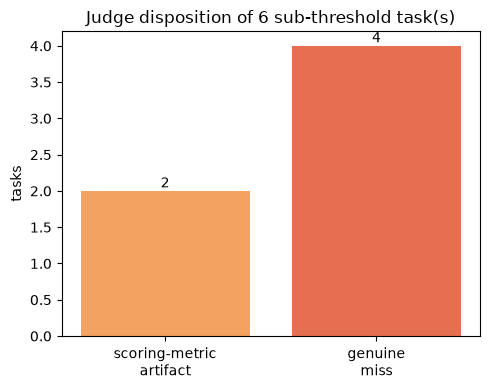

In [12]:
n_judged = len(judged_subset)
n_upgraded = int((judged_subset["judge_score"] >= 0.7).sum())
n_confirmed_wrong = n_judged - n_upgraded

if n_judged:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(
        ["scoring-metric\nartifact", "genuine\nmiss"],
        [n_upgraded, n_confirmed_wrong],
        color=["#f4a261", "#e76f51"],
    )
    ax.set_ylabel("tasks")
    ax.set_title(f"Judge disposition of {n_judged} sub-threshold task(s)")
    for i, v in enumerate([n_upgraded, n_confirmed_wrong]):
        ax.text(i, v + 0.05, str(v), ha="center")
    plt.tight_layout()
    charts.append(ChartImage(
        title="Judge disposition of sub-threshold tasks",
        caption="Of the tasks that scored below 0.70 on the deterministic metric, how many the LLM judge assessed as actually correct (a scoring-metric artifact) vs. genuinely wrong.",
        base64_png=fig_to_base64(fig),
        section="results",
    ))
    plt.show()
else:
    print("No sub-threshold tasks this run — nothing for the judge to review.")


<a id="reporting-template"></a>
## 📝 Testing Report

The deliverable of this scenario isn't the score table above — it's the report below. It's built from this same run's data (not written separately, so it can't drift out of sync with what was actually executed), and rendered through [`reporting/templates/scenario_report.html.j2`](../reporting/templates/scenario_report.html.j2) — **the same template every scenario in this repo uses**, so reports read the same way scenario to scenario. Each scenario can still add its own extra sections (see [`docs/drift_detection.md`](../docs/drift_detection.md) for the kind of scenario-specific content — noise-floor calibration, controlled-drift validation — that wouldn't fit the standard shape).

In [13]:
overall_n = len(combined["results"])
overall_pass_rate = combined["results"]["passed"].mean()
overall_avg_score = combined["results"]["score"].mean()

by_dataset = combined["summary"].groupby("dataset_label").apply(
    lambda g: pd.Series({
        "n": int(g["n"].sum()),
        "avg_score": round((g["avg_score"] * g["n"]).sum() / g["n"].sum(), 3),
        "pass_rate": round((g["pass_rate"] * g["n"]).sum() / g["n"].sum(), 3),
    })
).reset_index()
by_dataset["n"] = by_dataset["n"].astype(int)

# Built from this run's actual judge output, not hand-written, so it can't go stale on a re-run
# that produces a different mix of sub-threshold cases than the run this text was drafted against.
observations = []
next_steps = [
    "Wire `llm_judge_correctness` in as a proper secondary metric in `genai_capability_bench`, "
    "rather than the ad hoc post-hoc pass used here.",
    "Route any case where the judge disagrees with a human reviewer for adjudication, rather "
    "than trusting the same-model-family judge as final.",
]

custom_judged = judged_subset[judged_subset["dataset_label"] == "custom_golden_set"]
if len(custom_judged):
    custom_upgraded = int((custom_judged["judge_score"] >= 0.7).sum())
    observations.append(
        f"Sub-threshold scores are not automatically task failures — {custom_upgraded} of "
        f"{len(custom_judged)} sub-threshold case(s) in the **custom golden set** this run were "
        "judged substantively correct, because `short_answer_qa` under-credits a correct answer "
        "phrased as a full sentence rather than matching a short reference phrasing closely. Always "
        "read the judge's reasoning before treating a low score as a real miss."
    )

public_judged = judged_subset[judged_subset["dataset_label"] == "public_benchmark_sample"]
if len(public_judged):
    public_wrong = int((public_judged["judge_score"] < 0.7).sum())
    sand_flagged = "answer_accuracy_knowledge_v1_Mercury_7128923" in public_judged["task_id"].values
    obs = (
        f"The **public benchmark sample** told a different story: the judge confirmed {public_wrong} "
        f"of {len(public_judged)} sub-threshold case(s) as genuinely wrong, not scoring artifacts — "
        "a reminder that sub-threshold scores need to be checked, not assumed identical in cause "
        "across sub-datasets."
    )
    if sand_flagged:
        obs += (
            " One case is worth a caveat of its own — \"which substance retains the most energy "
            "from the Sun\" (gold answer \"sand\") is scientifically debatable on "
            "specific-heat-capacity grounds, a reminder that a public benchmark's gold answer isn't "
            "automatically ground truth either."
        )
    observations.append(obs)

empty_output_n = int(judged_subset["actual_output"].isna().sum())
if empty_output_n:
    observations.append(
        f"{empty_output_n} sub-threshold case(s) this run had no visible model output at all — an "
        "empty completion, not an error. This has now been observed across multiple runs of this "
        "notebook; the 300-token `max_completion_tokens` budget may be tight enough for a "
        "reasoning-family model to exhaust it on internal reasoning before producing a visible "
        "answer, rather than this being a one-off."
    )
    next_steps.insert(0, "Increase `max_completion_tokens` for this scenario's config and confirm the empty-completion cases stop recurring.")

observations.append(
    "Changing the target model changed the result: an earlier run of this exact scenario against a "
    "different model in the `gpt-5` family produced a materially different pass rate on the "
    "identical golden set. That's a live instance of Tier 2 — drift detection surfacing inside a "
    "Tier 1 test, and a concrete reason results here should be re-read after any model change."
)

report = ScenarioReport(
    scenario_name="Intended Performance",
    tier="Tier 1",
    risk="Silent task failure or plausible-looking wrong output.",
    goal="Performs its defined task correctly and completely.",
    target_summary={
        "Provider": "Azure OpenAI",
        "Model": target_model,
        "API version": api_version,
        "Generation config": "temperature omitted; max_completion_tokens token parameter (reasoning-family model)",
    },
    approach=(
        "Adapter onto `genai_capability_bench`'s `AnswerAccuracyEvaluator` via its stable "
        "`run_from_config` API (no evaluator/metric code duplicated). Two sub-datasets run through "
        "the identical harness and are reported side by side. Every task scoring below the 0.70 pass "
        "threshold gets an LLM-judge second opinion (same-model-family caveat noted below) rather "
        "than being taken at face value."
    ),
    data_sections=[
        DataSection(
            name="Custom HR/IT policy golden set",
            layer="Layer 6 — custom-authored",
            source="Hand-written for this repo",
            size=f"{len(golden_set)} tasks",
            description="Built to produce plausible-looking wrong answers via boundary values, negation, overriding exceptions, and conditional rules. Entirely synthetic.",
        ),
        DataSection(
            name="Public benchmark sample",
            layer="Layer 1 — generic benchmark",
            source="MMLU + TriviaQA + ARC, via genai_capability_bench's curated_knowledge_v1",
            size=f"{len(public_sample)} tasks (stratified from 33,156)",
            description="Reproducible, externally recognized benchmarks for breadth and comparability.",
        ),
    ],
    key_metrics=[
        Metric(value=f"{overall_avg_score:.2f}", label="Overall avg score", sublabel=f"n={overall_n}"),
        Metric(value=f"{overall_pass_rate:.0%}", label="Overall pass rate"),
        Metric(value=str(n_judged), label="Sub-threshold tasks reviewed by judge"),
        Metric(value=str(n_upgraded), label="Confirmed scoring-metric artifacts"),
        Metric(value=str(n_confirmed_wrong), label="Confirmed genuine misses"),
    ],
    results_tables=[
        ("Results by sub-dataset", by_dataset),
        ("Judge review of sub-threshold tasks", judged_subset[review_cols] if n_judged else judged_subset),
    ],
    charts=charts,
    observations=observations,
    next_steps=next_steps,
    notebook_link="../notebooks/01_intended_performance.ipynb",
    doc_link="../docs/intended_performance.md",
)

html = render_report(report)
report_path = save_report(html, "outputs/reports/intended_performance.html")
print(f"Report saved to {report_path}")
IFrame(src=str(report_path), width="100%", height=900)


Report saved to outputs/reports/intended_performance.html
